In [1]:
from cProfile import label

from cleo import color
# Para correr en Colab
%pip install roboticstoolbox-python
%pip install numpy==1.26.4 --force-reinstall

# Nota importante: da error porque un montón de bibliotecas de Colab dependen de numpy 2,
# pero como no se utilizan no importa.
#
# Cuando termina de ejecutarse la celda, pide reiniciar el kernel (aparece un botón bien evidente)
# Luego de reiniciar correr las celdas siguientes

Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-1.26.4-cp313-cp313-linux_x86_64.whl
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

In [3]:
def dp_animate(q,nombre , Ts=0.1, trail=False, interval=None):
    """
    Animación de doble péndulo a partir de coordenadas articulares

    Parámetros:
    - q: array (nq, N) trayectoria articular
    - Ts: paso de tiempo (s)
    - trail: True para dejar traza del extremo
    - interval: ms entre frames (default = Ts*1000)

    Retorna:
    - HTML para visualizar en notebook
    """
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    plt.rcParams["animation.html"] = "html5"

    N = q.shape[0]

    # --- calcular posiciones ---
    xy_codo = np.zeros((N, 3))
    xy_tool = np.zeros((N, 3))

    for i in range(N):
        q_i = q[i,:]

        T = dp.fkine_all(q_i)

        T_codo = T[1]
        T_tool = T[2]
        xy_codo[i, :] = T_codo.t
        xy_tool[i, :] = T_tool.t

    # base
    x0, y0 = 0.0, 0.0

    x1, y1 = xy_codo[:, 0], xy_codo[:, 1]
    x2, y2 = xy_tool[:, 0], xy_tool[:, 1]

    # --- figura ---
    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    all_x = np.concatenate(([x0], x1, x2))
    all_y = np.concatenate(([y0], y1, y2))
    margin = 0.2

    ax.set_xlim(all_x.min() - margin, all_x.max() + margin)
    ax.set_ylim(all_y.min() - margin, all_y.max() + margin)

    line, = ax.plot([], [], 'o-', lw=2)
    trail_line = None

    if trail:
        trail_line, = ax.plot([], [], '-', alpha=0.3)

    # --- animación ---
    def init():
        line.set_data([], [])
        if trail_line:
            trail_line.set_data([], [])
            return line, trail_line
        return (line,)

    def update(i):
        xs = [x0, x1[i], x2[i]]
        ys = [y0, y1[i], y2[i]]

        line.set_data(xs, ys)

        if trail_line:
            trail_line.set_data(x2[:i], y2[:i])
            return line, trail_line

        return (line,)

    if interval is None:
        interval = Ts * 1000

    ani = FuncAnimation(fig, update,
                        frames=N,
                        init_func=init,
                        interval=interval,
                        blit=True)

    plt.close(fig)

    ani.save(nombre)

    return HTML(ani.to_html5_video())

# Definición del modelo

In [26]:
dp = rtb.DHRobot(
    [
        rtb.RevoluteDH(a=0.2,m=1.5,
            r=np.array([-0.1, 0, 0]),
            I=np.array([0,0,0,0,0,0,0,0,1e-3]),
            B=0*1e-4, G=100),
        rtb.RevoluteDH(a=0.2,m=1,
            r=np.array([-0.1, 0, 0]),
            I=np.array([0,0,0,0,0,0,0,0,1e-4]),
            B=0*1e-4, G=100)
    ],
    gravity = np.array([0, -9.8, 0]), # Ojo con el signo, la gravedad va hacia abajo con signo positivo
    name="dp")

print(dp)
print(dp.dynamics())

DHRobot: dp, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬──────┬──────────────┬─────────────────────────────┬────┬────┬────────┬──────┐
│   j   │  m   │      r       │              I              │ Jm │ B  │   Tc   │  G   │
├───────┼──────┼──────────────┼─────────────────────────────┼────┼────┼────────┼──────┤
│ link1 │  1.5 │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0  │  0 │  0 │  0,  0 │  100 │
│ link2 │  1   │ -0.1,  0,  0 │  0,  0,  0.0001,  0,  0,  0 │  0 │  0 │  0,  0 │  100 │
└───────┴──────┴──────────────┴─────────────────────────────┴────┴────┴────────┴──────┘

None


Luego de definir el modelo con los parámetros físicos conocidos, se realizan pruebas para corroborar el funcionamiento esperado.

In [5]:
qr = np.array([-np.pi/2,0])
qz = np.zeros((2,))

**Equilibrio estable**

Se simula el robot desde un punto de equilibrio estable, con el objetivo de corroborar que el robot se mantiene en ese punto

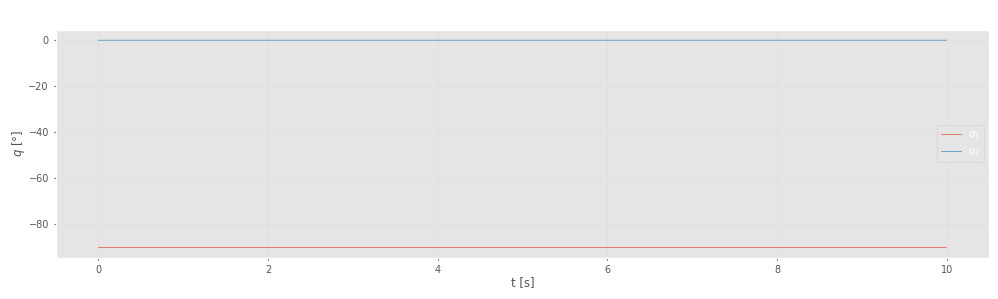

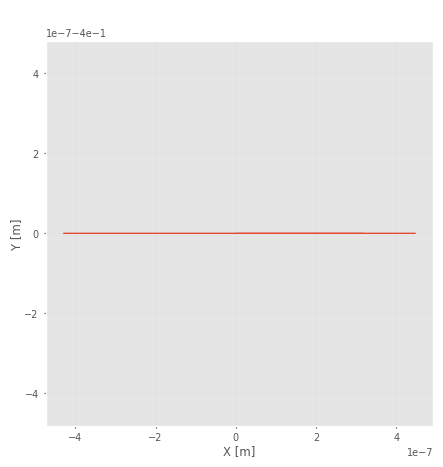

In [6]:
q_ini = np.array([-np.pi/2,0])

#tg = dp.nofriction(coulomb=False, viscous=False).fdyn(5, q_ini,qd0=np.zeros((2,)),dt=1e-3)
tg = dp.fdyn(10, q_ini,qd0=np.zeros((2,)),dt=1e-3)

plt.figure(figsize=(10,3))
plt.plot(tg.t.reshape(tg.t.shape[0],1) ,tg.q*180/np.pi)
plt.xlabel('t [s]')
plt.ylabel(r'$q$ [°]')
plt.legend([r'$q_1$',r'$q_2$'])
plt.title('Evolución de las variables articulares - Equilibrio estable')
plt.tight_layout()
plt.show()

trayectoria = dp.fkine(tg.q)
X = trayectoria.t[:,0]
Y = trayectoria.t[:,1]
Z = trayectoria.t[:,2]

plt.figure(figsize=(5,5))
plt.plot(X,Y)
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Trayectoria realizada - Equilibrio estable')
plt.axis('equal')
plt.show()

dp_animate(tg.q[0:-1:20], "equilibrio_estable.mp4", 1e-3*20)

Como se puede ver, el robot se mantiene cerca del punto de equilibrio, el unico desplazamiento que se puede apreciar es por los métodos numericos, y resulta evidente que su magnitud no es relevante comparada con el resto

**Equilibrio Inestable**

Se corrobora que, ante condiciones inciales en un punto de equilibrio inestable, el robot sale de este punto debido al ruido numerico.

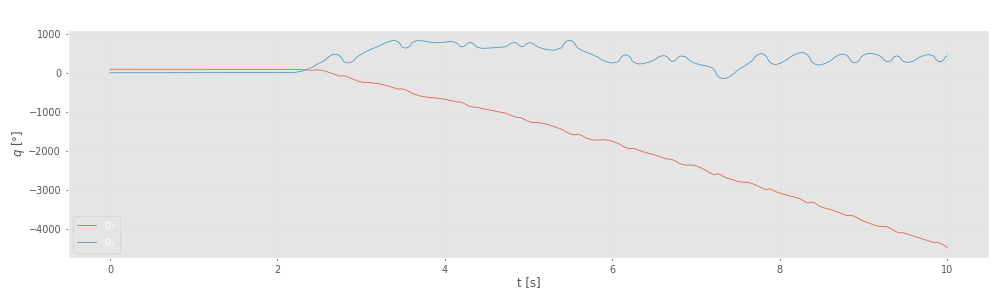

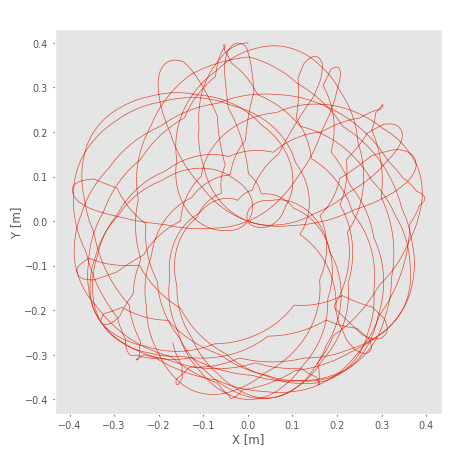

In [27]:
q_ini = np.array([np.pi/2,0])

#tg = dp.nofriction(coulomb=False, viscous=False).fdyn(5, q_ini,qd0=np.zeros((2,)),dt=1e-3)
tg = dp.fdyn(10, q_ini,qd0=np.zeros((2,)),dt=1e-3)

plt.figure(figsize=(10,3))
plt.plot(tg.t.reshape(tg.t.shape[0],1) ,tg.q*180/np.pi)
plt.xlabel('t [s]')
plt.ylabel(r'$q$ [°]')
plt.legend([r'$q_1$',r'$q_2$'])
plt.title('Evolución de las variables articulares - Equilibrio inestable')
plt.tight_layout()
plt.show()

trayectoria = dp.fkine(tg.q)
X = trayectoria.t[:,0]
Y = trayectoria.t[:,1]
Z = trayectoria.t[:,2]

plt.figure(figsize=(5,5))
plt.plot(X,Y)
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Trayectoria realizada - Equilibrio inestable')
plt.axis('equal')
plt.show()

dp_animate(tg.q[0:-1:20], "viento_numerico.mp4", 1e-3*20)

Se puede ver, en especial en el grafico de las variables articualres, como se mantiene en el punto de equilibrio por un tiempo hasta que el ruido de cálculo se vuelve lo sufientemente grande como para apertarlo del equilibrio.

**Comportamiento caotico**

Se espera que, ante pequeñas variaciones de las condiciones iniciales se presenten trayectorias con grandes diferencias.

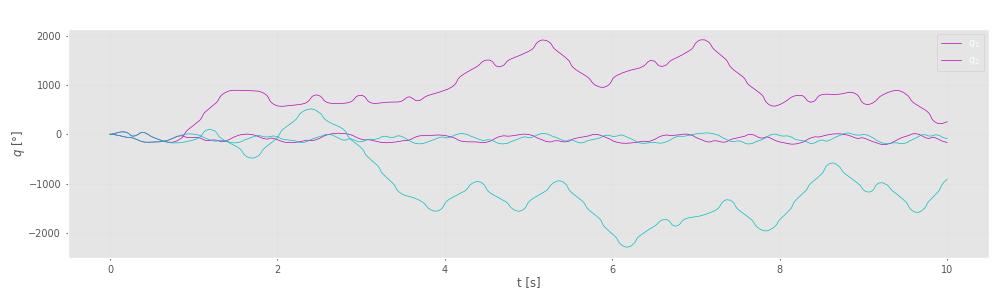

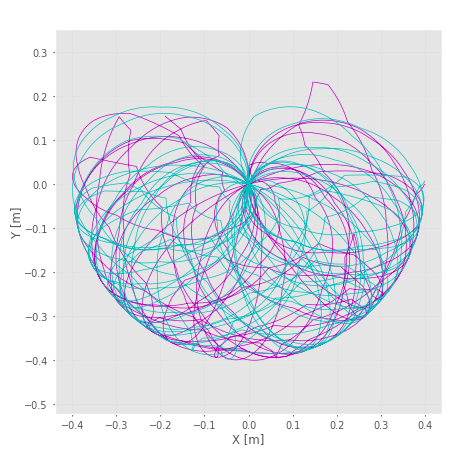

In [8]:
q_ini = np.array([0,0])

#tg = dp.nofriction(coulomb=False, viscous=False).fdyn(5, q_ini,qd0=np.zeros((2,)),dt=1e-3)
tg = dp.fdyn(10, q_ini,qd0=np.zeros((2,)),dt=1e-3)
tg_2 = dp.fdyn(10,q_ini + np.array([np.pi/180, 0]),qd0=np.zeros((2,)), dt=1e-3)

plt.figure(figsize=(10,3))
plt.plot(tg.t.reshape(tg.t.shape[0],1) ,tg.q*180/np.pi, color = 'm')
plt.plot(tg_2.t.reshape(tg_2.t.shape[0],1) ,tg_2.q*180/np.pi, color = 'c')
plt.xlabel('t [s]')
plt.ylabel(r'$q$ [°]')
plt.legend([r'$q_1$',r'$q_2$'])
plt.title('Evolución de las variables articulares - Caos')
plt.tight_layout()
plt.show()

trayectoria = dp.fkine(tg.q)
X = trayectoria.t[:,0]
Y = trayectoria.t[:,1]
Z = trayectoria.t[:,2]

trayectoria = dp.fkine(tg_2.q)
X_2 = trayectoria.t[:,0]
Y_2 = trayectoria.t[:,1]
Z_2 = trayectoria.t[:,2]



plt.figure(figsize=(5,5))
plt.plot(X,Y, color = 'm')
plt.plot(X_2,Y_2, color = 'c')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Trayectoria realizada - Caos')
plt.axis('equal')
plt.show()


Como se puede observar, las trayectorias son completamente distintas, aunque las condiciones inciales varien solo en un grado

**Conservación de la energia**

Al simular sin rozamiento, toda la energia potencial de las condiciones iniciales se convierte en energía cinética, y luego toda la energía se convierte en potencial, es decir, la energía total del sistema se conserva.

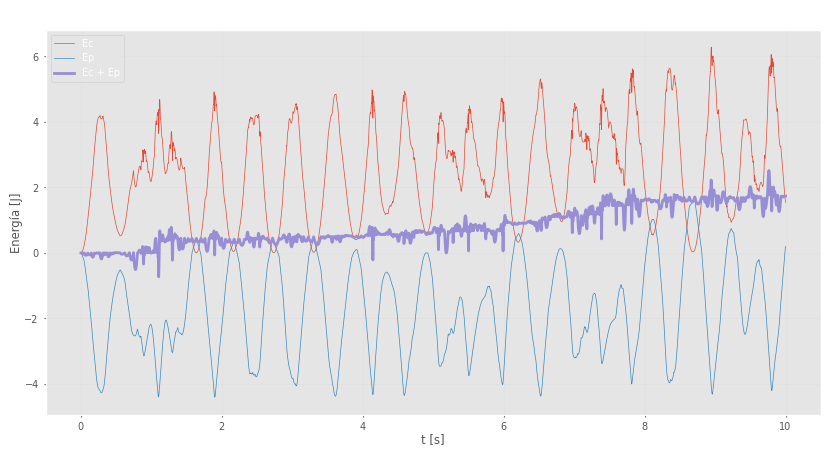

In [9]:
q_ini = np.array([0,0])

tg = dp.fdyn(10, q_ini,qd0=np.zeros((2,)),dt=1e-3)

Ec = np.zeros(len(tg.t))
Ep = np.zeros(len(tg.t))

gvec = dp.gravity

for k in range(len(tg.t)):

    q = tg.q[k]
    qd = tg.qd[k]

    # -----------------------------
    # Energía cinética
    # -----------------------------
    M = dp.inertia(q)

    Ec[k] = 0.5 * qd.T @ M @ qd

    # -----------------------------
    # Energía potencial
    # -----------------------------
    Ep_k = 0.0

    Tall = dp.fkine_all(q)

    for i, link in enumerate(dp.links):

        Tlink = Tall[i + 1].A

        p_com = Tlink @ np.r_[link.r, 1]

        p_com = p_com[:3]

        Ep_k += -link.m * gvec @ p_com

    Ep[k] = Ep_k

Et = Ec + Ep

plt.figure(figsize=(10,5))
plt.plot(tg.t, Ec, label='Ec')
plt.plot(tg.t, Ep, label='Ep')
plt.plot(tg.t, Et, label='Ec + Ep', linewidth=2)
plt.title('Conservacion de la energía')
plt.xlabel('t [s]')
plt.ylabel('Energía [J]')
plt.grid(True)
plt.legend()
plt.show()

Se puede apreciar como, incialmente se cumple lo supuesto, pero al pasar el tiempo el valor de energía se empieza a desplazar de la inicial, esto se atribuye prinicipalmente a los errores numéricos, que se vuelven más evidentes al evaluar las velocidades del sistema.

**Modelado con rozamiento**

Se redefine el robot, esta vez con rozamiento no nulo.

In [10]:
dp = rtb.DHRobot(
    [
        rtb.RevoluteDH(a=0.2,m=1.5,
            r=np.array([-0.1, 0, 0]),
            I=np.array([0,0,0,0,0,0,0,0,1e-3]),
            B=0.4e-3, G=100),
        rtb.RevoluteDH(a=0.2,m=1,
            r=np.array([-0.1, 0, 0]),
            I=np.array([0,0,0,0,0,0,0,0,1e-4]),
            B=0.1e-3, G=100)
    ],
    gravity = np.array([0, -9.8, 0]), # Ojo con el signo, la gravedad va hacia abajo con signo positivo
    name="dp")

print(dp)
print(dp.dynamics())

DHRobot: dp, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬──────┬──────────────┬─────────────────────────────┬────┬─────────┬────────┬──────┐
│   j   │  m   │      r       │              I              │ Jm │    B    │   Tc   │  G   │
├───────┼──────┼──────────────┼─────────────────────────────┼────┼─────────┼────────┼──────┤
│ link1 │  1.5 │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0  │  0 │  0.0004 │  0,  0 │  100 │
│ link2 │  1   │ -0.1,  0,  0 │  0,  0,  0.0001,  0,  0,  0 │  0 │  0.0001 │  0,  0 │  100 │
└───────┴──────┴──────────────┴─────────────────────────────┴────┴─────────┴────────┴──────┘

None


Se simula el robot desde un punto apartado del equilibrio, con el objetivo de ver la vuelta a este y la permanencia, debido a la accion de la fuerzas no conservativas.

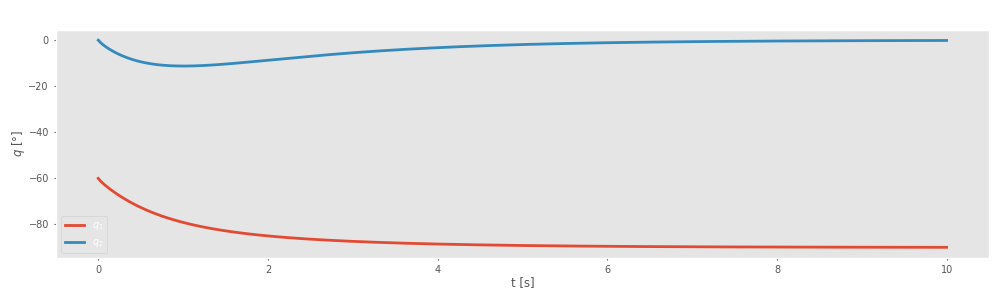

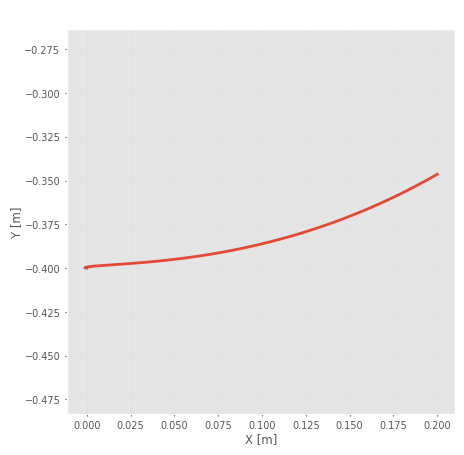

In [11]:


q_ini = np.array([-np.pi/3,0])

#tg = dp.nofriction(coulomb=False, viscous=False).fdyn(5, q_ini,qd0=np.zeros((2,)),dt=1e-3)
tg = dp.fdyn(10, q_ini,qd0=q_ini,dt=1e-3)

plt.figure(figsize=(10,3))
plt.plot(tg.t.reshape(tg.t.shape[0],1) ,tg.q*180/np.pi, linewidth=2)
plt.xlabel('t [s]')
plt.ylabel(r'$q$ [°]')
plt.legend([r'$q_1$',r'$q_2$'])
plt.title('Evolución de las variables articulares - Vuelta al equilibrio')
plt.grid()
plt.tight_layout()
plt.show()

trayectoria = dp.fkine(tg.q)
X = trayectoria.t[:,0]
Y = trayectoria.t[:,1]
Z = trayectoria.t[:,2]

plt.figure(figsize=(5,5))
plt.plot(X,Y, linewidth=2)
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Trayectoria realizada - Vuelta al equilibrio')
plt.axis('equal')
plt.show()

dp_animate(tg.q[0:-1:20], "con_rozamiento.mp4", 1e-3*20)

Se puede observar como los ángulos vuelven al valor de equilibrio, como es esperado.

# Control

**Calculo de las constantes**

Para el control proporcional derivativo, se puede calcular la transferencia, que luego de compararla con el polinomio carácteristico se puede obtener una expresión de las constantes proporcional y derivativa en funcion de los factores de amortiguamiento y los $\omega_n$

$$k_p = \frac{\omega_n^2 J_{ef}}{N K_m} $$
$$k_d = \frac{J_{ef} 2 \zeta \omega_n - B_{ef}}{N K_m}$$

N es la reduccion de los motores, $K_m$ relaciona las corrientes de entrada a los motores con los torques, como usamos directamente torques como accion de control, tomamos $K_m$ y N = 1

Los $J_m$ tambien son cero porque por ahora se ignora la existencia de los motores


In [12]:
K_m = 1

N = 1

Jef = np.array([dp.links[0].Jm,
dp.links[1].Jm])*N*N +  np.array([dp.links[0].m,
dp.links[1].m])

Bef = np.array([dp.links[0].B,
dp.links[1].B])*N*N

zeta_PD = np.array([0.3,0.2])

wn_PD = np.array([14,5])

Kp_PD = np.diag((wn_PD**2 * Jef )/ (N*K_m))
Kd_PD = np.diag((Jef*2*zeta_PD*wn_PD-Bef)/(N*K_m))
print(Kp_PD)
print(Kd_PD)

[[294.   0.]
 [  0.  25.]]
[[12.5996  0.    ]
 [ 0.      1.9999]]


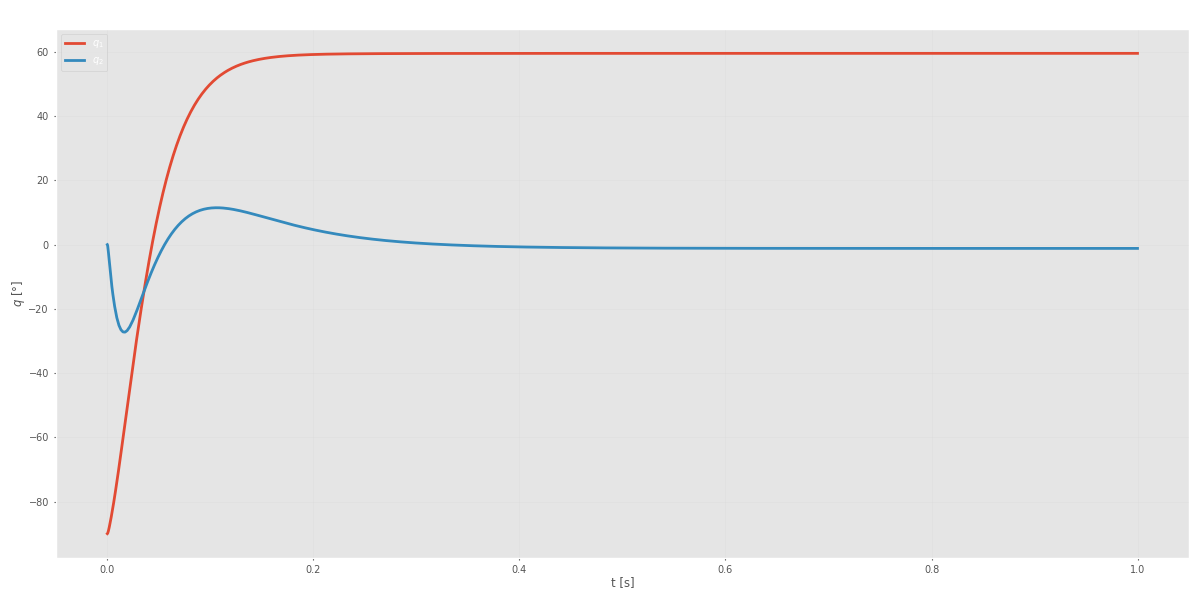

In [13]:
def controlPD(robot, t, q, qd, q_deseado, Kp, Kd):
    return Kp.dot(q_deseado - q) - Kd.dot(qd)


q_deseado = np.array([np.pi/3,0])

tg = dp.nofriction(True,True).fdyn(1, qr, Q=controlPD, Q_args={'q_deseado':q_deseado, 'Kp':Kp_PD, 'Kd':Kd_PD},dt=1e-4)

plt.figure(figsize=(12,6))
plt.plot(tg.t,tg.q*180/np.pi, linewidth=2)
plt.xlabel('t [s]')
plt.ylabel(r'$q$ [°]')
plt.legend([r'$q_1$',r'$q_2$'])
plt.title('Evolución de las variables articulares')
plt.tight_layout()
plt.show()

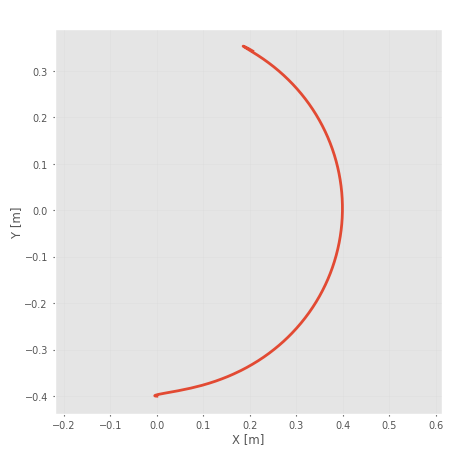

In [14]:
trayectoria = dp.fkine(tg.q)
X = trayectoria.t[:,0]
Y = trayectoria.t[:,1]
Z = trayectoria.t[:,2]

plt.figure(figsize=(5,5))
plt.plot(X,Y, linewidth=2)
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Trayectoria realizada')
plt.axis('equal')
plt.show()

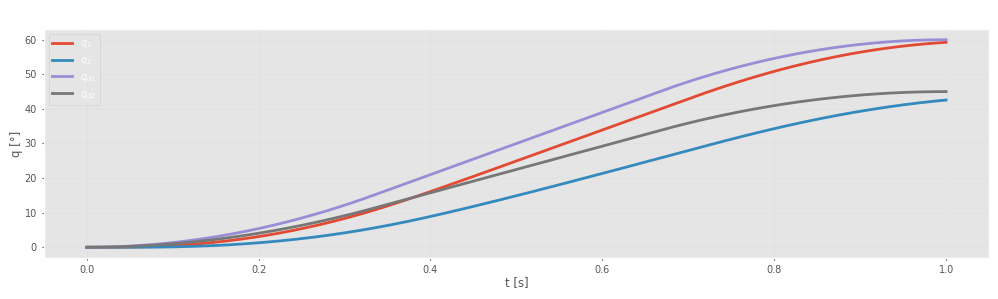

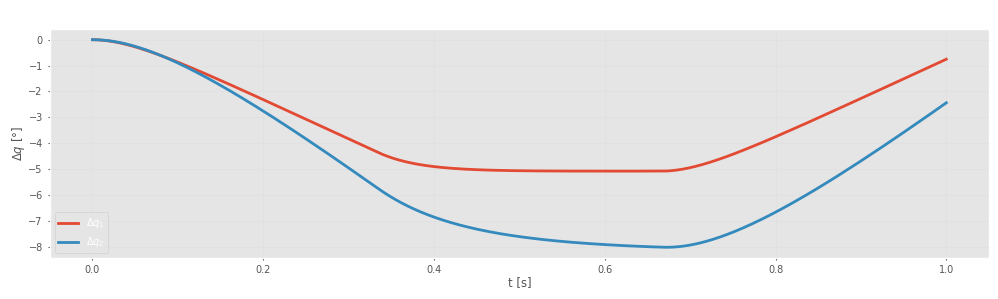

In [15]:
# Evaluo la respuesta a una trayectoria
dt = 1e-4
n_samples = 10000
Tspan = n_samples * dt
t = np.arange(0,Tspan,dt)

q_des = rtb.mtraj(rtb.trapezoidal, qz, [np.pi/3,np.pi/4], t).q

def controlPD(robot, t, q, qd, q_deseado, Kp, Kd):
    idx = np.round(t/dt).astype(int)
    if idx>=n_samples:
      idx=-1
    q_ref = q_deseado[idx,:]
    # problema: el integrador toma mas muestras? ---> paso variable ??
    return Kp.dot(q_ref - q) - Kd.dot(qd) + robot.gravload(q)

tg = dp.nofriction(True,False).fdyn(1, qz, Q=controlPD, Q_args={'q_deseado':q_des, 'Kp':Kp_PD, 'Kd':Kd_PD},dt=1e-4)

plt.figure(figsize=(10,3))
plt.plot(tg.t,tg.q*180/np.pi, linewidth=2)
plt.plot(tg.t,q_des*180/np.pi, linewidth=2)
plt.xlabel('t [s]')
plt.ylabel('q [°]')
plt.legend([r'$q_1$',r'$q_2$',r'$q_{d1}$',r'$q_{d2}$'])
plt.title('Evolución de las variables articulares')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(tg.t,(tg.q-q_des)*180/np.pi, linewidth=2)
plt.xlabel('t [s]')
plt.ylabel(r'$\Delta q$ [°]')
plt.legend([r'$\Delta q_1$',r'$\Delta q_2$'])
plt.title('Error')
plt.tight_layout()
plt.show()


dp_animate(tg.q[0:-1:20], "control_PD.mp4", 1e-4*20)


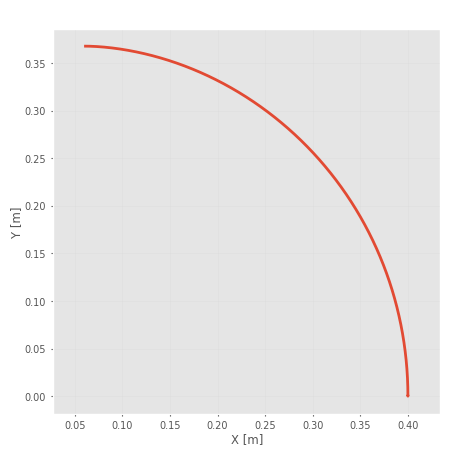

In [16]:
trayectoria = dp.fkine(tg.q)
X = trayectoria.t[:,0]
Y = trayectoria.t[:,1]
Z = trayectoria.t[:,2]

plt.figure(figsize=(5,5))
plt.plot(X,Y, linewidth=2)
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Trayectoria realizada')
plt.axis('equal')
plt.show()

# Control PD Digital

In [17]:
from scipy.integrate import solve_ivp

def f(t, x, tau):
    n = len(x)//2
    q = x[:n]
    qd = x[n:]

    qdd = dp.accel(q,qd,tau)

    return np.hstack((qd, qdd))

100%|██████████| 1500/1500 [00:01<00:00, 773.86it/s]


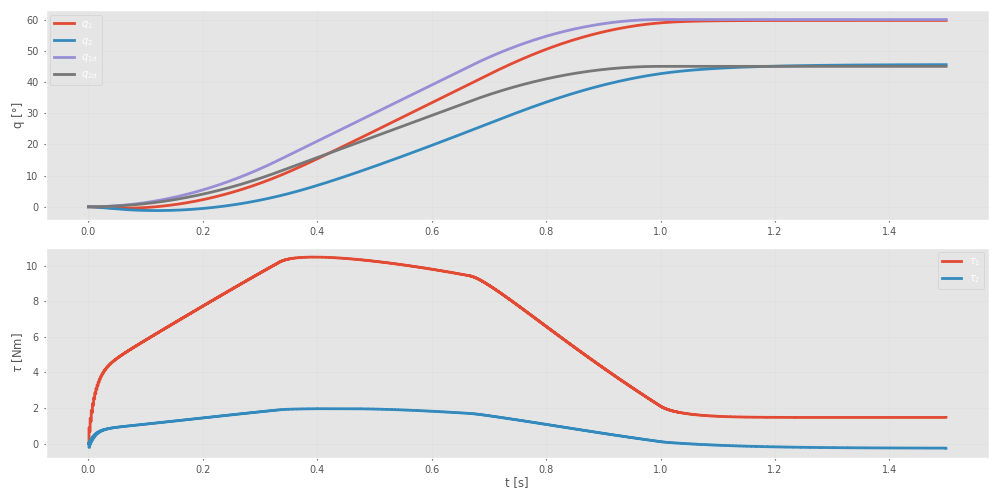

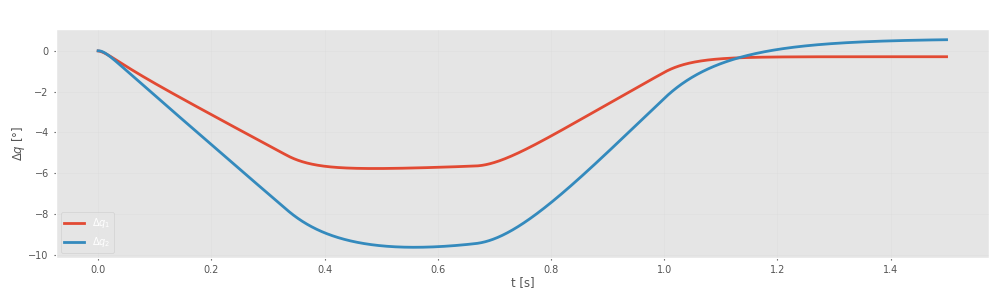

In [18]:
from tqdm import tqdm
# Evaluo la respuesta a una trayectoria

# Configuro la base de tiempo de la simulación
dt = 1e-3
samples_estacionario = 500
n_samples = 1000 + samples_estacionario
Tspan_estacionario = samples_estacionario*dt
Tspan = n_samples * dt
t_inicial = np.arange(0,Tspan - Tspan_estacionario,dt)
t_estacionario = np.arange(Tspan - Tspan_estacionario,Tspan,dt)

t = np.arange(0,Tspan,dt)

# Condición inicial
q = qz
qd = np.zeros_like(q)
x = np.hstack((q,qd))

# Calculo offline las referencias
q_des_ini = rtb.mtraj(rtb.trapezoidal, qz, [np.pi/3,np.pi/4], t_inicial).q
q_des_est = rtb.mtraj(rtb.trapezoidal, [np.pi/3,np.pi/4],[np.pi/3,np.pi/4], t_estacionario).q

q_des = np.vstack((q_des_ini, q_des_est))

# Defino vectores para almacenar datos
q_samples = np.zeros((n_samples,len(q)))
qd_samples = np.zeros((n_samples,len(q)))
tau_samples = np.zeros((n_samples,len(q)))

for i in tqdm(range(n_samples)):
   # Obtengo la referencia para el instante actual
   q_ref = q_des[i]
   # Calculo la acción de control para el instante de tiempo actual
   tau = Kp_PD.dot(q_ref - x[:2]) - Kd_PD.dot(x[2:]) #+ dp.gravload(x[:2])

# Integración de tiempo continuo en un paso con tau constante
   sol = solve_ivp(
        lambda t, x_: f(t, x_, tau),
        [0, dt],
        x,
        method='RK45',
        t_eval=[dt],   # solo me interesa el final
        rtol=1e-6,
        atol=1e-9
    )

   # Actualizo los estados
   x = sol.y[:,-1]

   # Almaceno resultados para graficar luego
   q_samples[i,:] = x[:2]
   qd_samples[i,:] = x[2:]
   tau_samples[i,:] = tau

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t,q_samples*180/np.pi,linewidth=2)
plt.plot(t,q_des*180/np.pi, linewidth=2)
plt.ylabel('q [°]')
plt.legend([r'$q_1$',r'$q_2$',r'$q_{1d}$',r'$q_{2d}$'])
plt.subplot(2,1,2)
plt.step(t,tau_samples,where='post', linewidth=2)
plt.legend([r'$\tau_1$',r'$\tau_2$'])
plt.ylabel(r'$\tau$ [Nm]')
plt.xlabel('t [s]')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(t,(q_samples-q_des)*180/np.pi, linewidth=2)
plt.xlabel('t [s]')
plt.ylabel(r'$\Delta q$ [°]')
plt.legend([r'$\Delta q_1$',r'$\Delta q_2$'])
plt.title('Error')
plt.tight_layout()
plt.show()

dp_animate(q_samples[0:-1:20], "control_PD_dig.mp4", 1e-3*20)

# Control PID

In [19]:
def f(t, x, tau):
    n = len(x)//2
    q = x[:n]
    qd = x[n:]

    qdd = dp.accel(q,qd,tau)

    return np.hstack((qd, qdd))

100%|██████████| 2000/2000 [00:02<00:00, 695.43it/s]


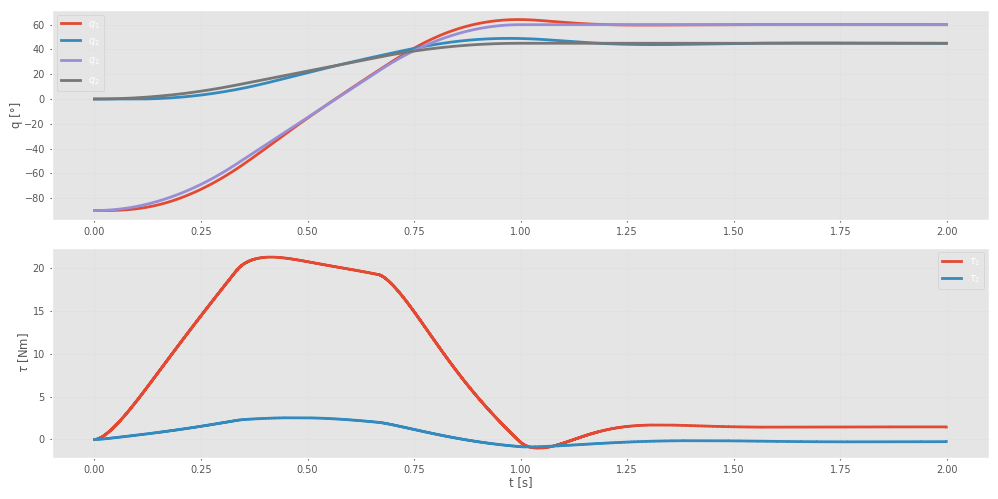

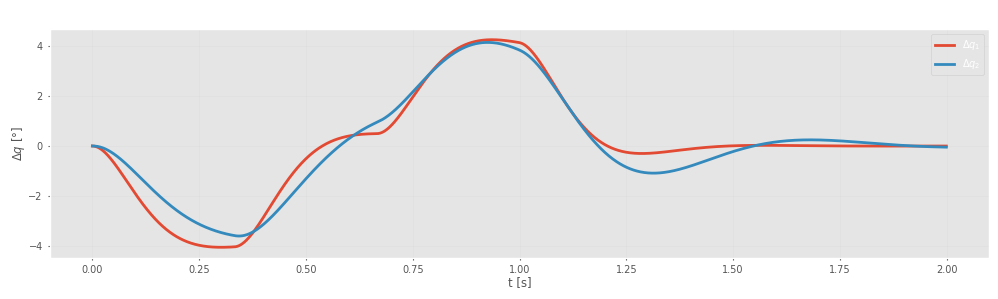

In [20]:
from tqdm import tqdm
# Evaluo la respuesta a una trayectoria

q_abajo = np.array([-np.pi/2, 0])

# Configuro la base de tiempo de la simulación
dt = 1e-3
samples_estacionario = 1000
n_samples = 1000 + samples_estacionario
Tspan_estacionario = samples_estacionario*dt
Tspan = n_samples * dt
t_inicial = np.arange(0,Tspan - Tspan_estacionario,dt)
t_estacionario = np.arange(Tspan - Tspan_estacionario,Tspan,dt)

t = np.arange(0,Tspan,dt)

# Condición inicial
q = q_abajo
qd = np.zeros_like(q)
x = np.hstack((q,qd))

# Calculo offline las referencias
q_des_ini = rtb.mtraj(rtb.trapezoidal, q_abajo, [np.pi/3,np.pi/4], t_inicial).q
q_des_est = rtb.mtraj(rtb.trapezoidal, [np.pi/3,np.pi/4],[np.pi/3,np.pi/4], t_estacionario).q

q_des = np.vstack((q_des_ini, q_des_est))


# Defino vectores para almacenar datos
q_samples = np.zeros((n_samples,len(q)))
qd_samples = np.zeros((n_samples,len(q)))
tau_samples = np.zeros((n_samples,len(q)))

# Variables para control integral

I = 0

e_ant = 0

for i in tqdm(range(n_samples)):
   # Obtengo la referencia para el instante actual
   q_ref = q_des[i]
   # Calculo la acción de control para el instante de tiempo actual
   error = q_ref - x[:2]
   I += 0.5 * dt * (error + e_ant)
   tau = Kp_PD.dot(error) - Kd_PD.dot(x[2:]) + Kp_PD.dot(I)/(0.1) #+ dp.gravload(x[:2])
   e_ant = error

# Integración de tiempo continuo en un paso con tau constante
   sol = solve_ivp(
        lambda t, x_: f(t, x_, tau),
        [0, dt],
        x,
        method='RK45',
        t_eval=[dt],   # solo me interesa el final
        rtol=1e-6,
        atol=1e-9
    )

   # Actualizo los estados
   x = sol.y[:,-1]

   # Almaceno resultados para graficar luego
   q_samples[i,:] = x[:2]
   qd_samples[i,:] = x[2:]
   tau_samples[i,:] = tau

plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
plt.plot(t,q_samples*180/np.pi, linewidth=2)
plt.plot(t,q_des*180/np.pi, linewidth=2)
plt.ylabel('q [°]')
plt.legend([r'$q_1$',r'$q_2$',r'$\dot{q}_1$',r'$\dot{q}_2$'])
plt.subplot(2,1,2)
plt.step(t,tau_samples,where='post', linewidth=2)
plt.legend([r'$\tau_1$',r'$\tau_2$'])
plt.ylabel(r'$\tau$ [Nm]')
plt.xlabel('t [s]')
plt.tight_layout()
plt.savefig("treyectoria_pid_digital.pdf")
plt.show()

plt.figure(figsize=(10,3))
plt.plot(t,(q_samples-q_des)*180/np.pi, linewidth=2)
plt.xlabel('t [s]')
plt.ylabel(r'$\Delta q$ [°]')
plt.legend([r'$\Delta q_1$',r'$\Delta q_2$'])
plt.title('Error')
plt.tight_layout()
plt.show()

dp_animate(q_samples[0:-1:20], "control_PID.mp4", 1e-3*20)

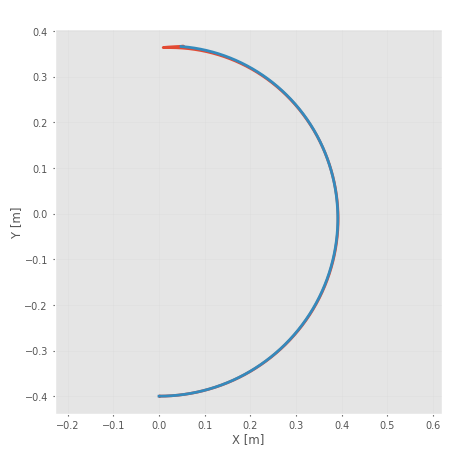

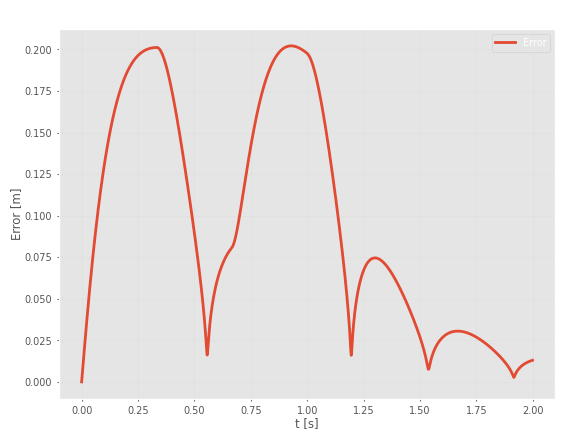

In [21]:
trayectoria_real = dp.fkine(q_samples)
X_real = trayectoria_real.t[:,0]
Y_real = trayectoria_real.t[:,1]
Z_real = trayectoria_real.t[:,2]

xyz_real = np.vstack((X_real,Y_real,Z_real))

trayectoria_esperada = dp.fkine(q_des)
X_esperado = trayectoria_esperada.t[:,0]
Y_esperado = trayectoria_esperada.t[:,1]
Z_esperado = trayectoria_esperada.t[:,2]

xyz_esperado = np.vstack((X_esperado,Y_esperado,Z_esperado))


plt.figure(figsize=(5,5))
plt.plot(X_real,Y_real, linewidth=2, label='Real')
plt.plot(X_esperado,Y_esperado, linewidth=2, label='Esperado')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Trayectoria realizada')
plt.axis('equal')

plt.figure()
plt.plot(t,np.sqrt(np.linalg.norm(xyz_real-xyz_esperado, axis = 0)), linewidth=2, label='Error')
plt.xlabel('t [s]')
plt.ylabel('Error [m]')
plt.title('Error')
plt.legend()

plt.show()

# PD + FF

In [22]:
K_m = 1

N = 1

Jef = np.array([dp.links[0].Jm,
dp.links[1].Jm])*N*N +  np.array([dp.links[0].m,
dp.links[1].m])

Bef = np.array([dp.links[0].B,
dp.links[1].B])*N*N

zeta_PD_FF = np.array([1,1])

wn_PD_FF = np.array([20,15])

Kp_PD_FF = np.diag((wn_PD_FF**2 * Jef )/ (N*K_m))
Kd_PD_FF = np.diag((Jef*2*zeta_PD_FF*wn_PD_FF-Bef)/(N*K_m))
print(Kp_PD_FF)
print(Kd_PD_FF)

[[600.   0.]
 [  0. 225.]]
[[59.9996  0.    ]
 [ 0.     29.9999]]


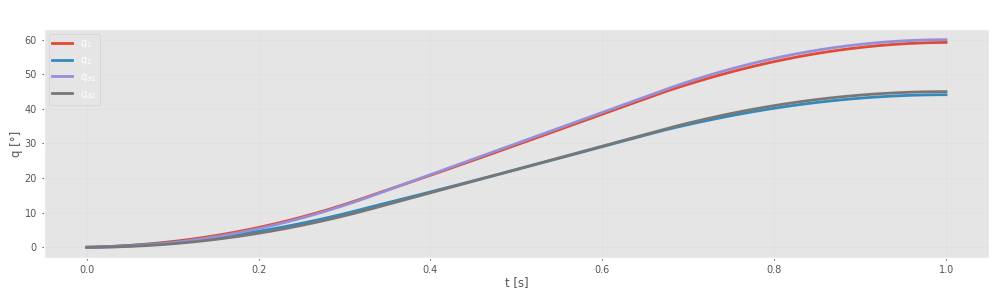

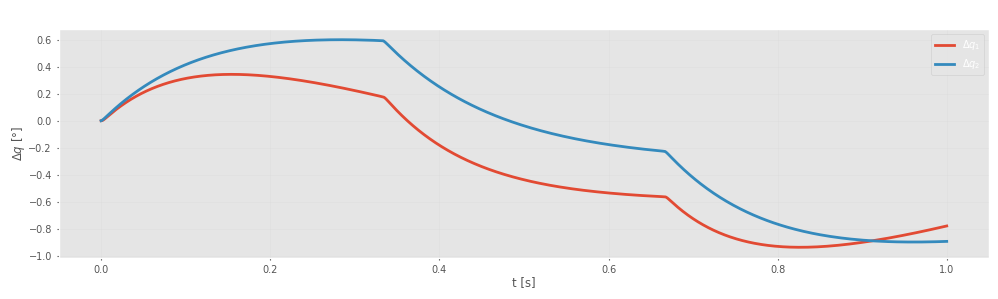

In [23]:
# Evaluo la respuesta a una trayectoria
dt = 1e-4
n_samples = 10000
Tspan = n_samples * dt
t = np.arange(0,Tspan,dt)

trayectoria = rtb.mtraj(rtb.trapezoidal, qz, [np.pi/3,np.pi/4], t)

q_des = trayectoria.q
qp_des = trayectoria.qd
qpp_des= trayectoria.qdd

def controlPD(robot, t, q, qd, q_deseado, qp_deseado,qpp_deseado,  Kp, Kd):
    idx = np.round(t/dt).astype(int)
    if idx>=n_samples:
      idx=-1
    q_ref = q_deseado[idx,:]
    qp_ref = qp_deseado[idx,:]
    qpp_ref = qpp_deseado[idx,:]
    error = q_ref-q
    # problema: el integrador toma mas muestras? ---> paso variable ??
    return Kp_PD_FF.dot(error) + Kd_PD_FF.dot(qp_ref - qd) + ((np.array([dp.links[0].Jm,
dp.links[1].Jm])*N*N +  np.array([dp.links[0].m,
dp.links[1].m]))/(N*K_m))*qpp_ref + (Bef*N/(K_m))*qp_ref + + dp.gravload(q)

tg = dp.nofriction(True,False).fdyn(1, qz, Q=controlPD, Q_args={'q_deseado':q_des,'qp_deseado': qp_des,'qpp_deseado':qpp_des, 'Kp':Kp_PD_FF, 'Kd':Kd_PD_FF},dt=1e-4)

plt.figure(figsize=(10,3))
plt.plot(tg.t,tg.q*180/np.pi, linewidth=2)
plt.plot(tg.t,q_des*180/np.pi, linewidth=2)
plt.xlabel('t [s]')
plt.ylabel('q [°]')
plt.legend([r'$q_1$',r'$q_2$',r'$q_{d1}$',r'$q_{d2}$'])
plt.title('Evolución de las variables articulares')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(tg.t,(tg.q-q_des)*180/np.pi, linewidth=2)
plt.xlabel('t [s]')
plt.ylabel(r'$\Delta q$ [°]')
plt.legend([r'$\Delta q_1$',r'$\Delta q_2$'])
plt.title('Error')
plt.tight_layout()
plt.show()

dp_animate(tg.q[0:-1:20], "control_PD_FF.mp4", 1e-4*20)

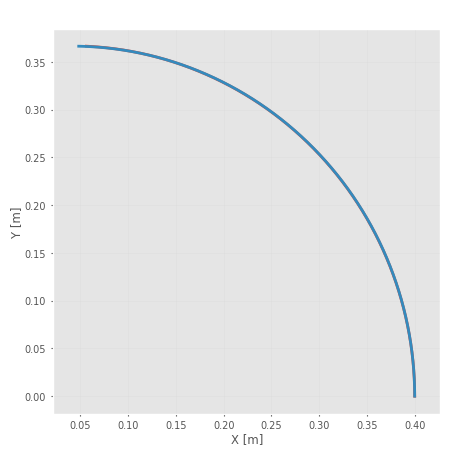

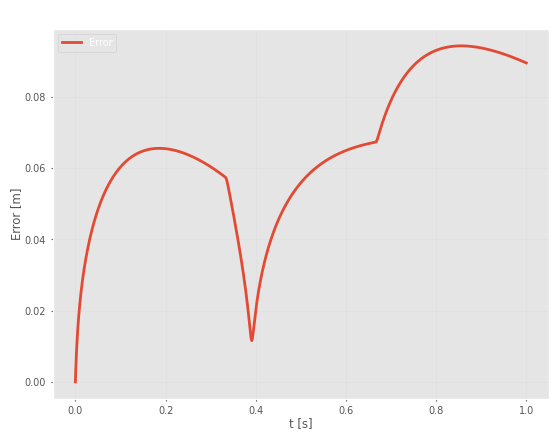

In [24]:
trayectoria_real = dp.fkine(tg.q)
X_real = trayectoria_real.t[:,0]
Y_real = trayectoria_real.t[:,1]
Z_real = trayectoria_real.t[:,2]

xyz_real = np.vstack((X_real,Y_real,Z_real))

trayectoria_esperada = dp.fkine(q_des)
X_esperado = trayectoria_esperada.t[:,0]
Y_esperado = trayectoria_esperada.t[:,1]
Z_esperado = trayectoria_esperada.t[:,2]

xyz_esperado = np.vstack((X_esperado,Y_esperado,Z_esperado))


plt.figure(figsize=(5,5))
plt.plot(X_real,Y_real, linewidth=2, label='Real')
plt.plot(X_esperado,Y_esperado, linewidth=2, label='Esperado')
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Trayectoria realizada')
plt.axis('equal')

plt.figure()
plt.plot(t,np.sqrt(np.linalg.norm(xyz_real-xyz_esperado, axis = 0)), linewidth=2, label='Error')
plt.xlabel('t [s]')
plt.ylabel('Error [m]')
plt.title('Error')
plt.legend()

plt.show()